# FLASH Soil Saturation Diagnostics
## Prototype Analysis Notebook (Single Case)
------

### Notebook Setup

In [20]:
# Let's import the needed libraries
import wfutilities as wf

import    urllib.request# helps us download files from the internet
import    gzip          # helps us unzip .gz files
import    tempfile      # creates a temporary file that will disappear later
import    xarray as xr  # the best tool to read weather raster files
from datetime import datetime # handles date and time
from datetime import timedelta # Manipulating time
import numpy as np               # for arrays and math (np = nickname)
import matplotlib.pyplot as plt  # main plotting tool (plt = nickname)
import cartopy.crs as ccrs       # map projections
import cartopy.feature as cfeature  # add states, coastlines, etc.
import numpy.ma as ma            # mask/hide bad values
from metpy.plots import ctables  # official radar colors
import matplotlib.colors as mcolors
import os
import requests

# Core scientific Python stack
import pandas as pd
import rasterio
import rioxarray as rxr
from rasterio.enums import Resampling
import geopandas as gpd

# NLDAS Access
import earthaccess

# ML tools
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Image / segmentation utilities
from scipy import ndimage

### Step 1 - Define the Analysis Case
This section has three steps:

- Parse a string → datetime object
- Extract components from the datetime object
- Format those components back into strings for URLs, paths, or filenames

“We parse date‑time strings into Python’s datetime objects so we can extract and format year, month, day, and time components reliably when constructing file paths and URLs.”

In [3]:
# Let's import the needed libraries
import wfutilities as wf

In [28]:
# ===============================
# USER-DEFINED CONFIGURATION
# ===============================

case_date = "2019-05-27"
case_time = "00:00"  # UTC

# Simple bounding box (Iowa region)
lon_min, lon_max = -130, -60 #-97.5, -90.0
lat_min, lat_max = 24,50 #40.0, 45

# Parse it into a datetime object
case_dt = datetime.strptime(case_date + " " + case_time, "%Y-%m-%d %H:%M")

# # Accessing Date Components Directly
# year  = case_dt.year
# month = case_dt.month
# day   = case_dt.day
# hour  = case_dt.hour
# minute = case_dt.minute


### Step 2 — Download and Load Data
#### FLASH data from ISU Mesonet Archive (CREST Soil Saturation & Unit Q)

#### Download Specific Products

In [30]:
## FLASH UNIT Q Layer
flas_uq_da = wf.downloadFLASH("CREST_MAXUNITSTREAMFLOW",case_dt)

## FLASH SOILSAT Layer
flas_soil_da = wf.downloadFLASH("CREST_MAXSOILSAT",case_dt)

https://mtarchive.geol.iastate.edu/2019/05/27/mrms/ncep/FLASH/CREST_MAXUNITSTREAMFLOW/CREST_MAXUNITSTREAMFLOW_00.00_20190527-000000.grib2.gz
   → Got the file! Size: 2,250,101 bytes (compressed)
Starting to unzip and load the radar file...
   → Unzipped! New size = 2,318,259 bytes
   → Unzipped file saved temporarily at: /tmp/tmpqbjulbex.grib2
https://mtarchive.geol.iastate.edu/2019/05/27/mrms/ncep/FLASH/CREST_MAXSOILSAT/CREST_MAXSOILSAT_00.00_20190527-000000.grib2.gz
   → Got the file! Size: 3,292,786 bytes (compressed)
Starting to unzip and load the radar file...
   → Unzipped! New size = 3,364,050 bytes
   → Unzipped file saved temporarily at: /tmp/tmp6i1c7zt3.grib2


#### NLDAS Layers
 Download outputs from the NOAH-MP Land Surface model - More information at https://ldas.gsfc.nasa.gov/nldas

In [31]:
# NLDAS
dowloadNLDAS
# Login (only once per machine)
earthaccess.login(persist=True)

# Download ONE real file
results = earthaccess.search_data(
    short_name="NLDAS_NOAH0125_H",
    version="2.0",
    temporal=case_dt.strftime("%Y-%m-%d %H:%M"), # ("2024-12-25 10:00", "2024-05-27 20:00"), #case_dt.strftime("%Y-%m-%d %H:%M"), # 
    count=1
)

print(f"Found {len(results)} granule")

files = earthaccess.download(results, "./nldas_data/")
local_file = files[0]
# print("File:", local_file)

# Open with xarray
ds_nldas = xr.open_dataset(local_file, engine="netcdf4")
# print(ds_nldas.variables)

Found 1 granule


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [33]:
# Map NLDAS Soil layers onto FLASH Soil Saturation Definition

# Load in the Depth-to-Bedrock layer used in FLASH to determine Maximum Soil Depth (cm)
with rasterio.open("RockDepth_1km_mrms_grid.tif") as src:
    soil_depth = src.read(1)        # NumPy array
    transform = src.transform
    crs = src.crs
    nodata = src.nodata

# Load in the Effective Porosity layer used in FLASH to determine Maximum Water Capacity
with rasterio.open("Effective_Porosity_FLASH_MRMS_1km.tif") as src:
    soil_eff_porosity = src.read(1)        # NumPy array
    # transform = src.transform
    # crs = src.crs
    # nodata = src.nodata

# Resample and Reproject NLDAS to FLASH grid
# soil100cm_nldas = ds_nldas["SMAvail_0_200cm"]

# soil100cm_nldas = ds_nldas["SoilM_0_200cm"]

def nldas2FLASH(nldas_layer,flash_layer):
    nldas_layer = nldas_layer.rename({"lon": "x", "lat": "y"})

    # Activate rioxarray
    nldas_layer = nldas_layer.rio.set_spatial_dims(x_dim="x", y_dim="y")
    nldas_layer = nldas_layer.rio.write_crs("EPSG:4326")
    nldas_layer = nldas_layer.rio.write_transform()
    
    # Reproject / resample
    warped_nldas_layer = nldas_layer.rio.reproject(
        "EPSG:4326",
        resolution=0.01,
        resampling=Resampling.bilinear        
    )
    
    # Get bounding box of reference raster
    minx, miny, maxx, maxy = flash_layer.rio.bounds()
    
    nldas_mrmsgrid = warped_nldas_layer.rio.reproject_match(flash_layer)

    return nldas_mrmsgrid

# Transform NLDAS layers to MRMS-FLASH grid conventions
# 0 - 200 cm
soil200cm_nldas_mrmsgrid = nldas2FLASH(ds_nldas["SoilM_0_200cm"],flas_uq_da)
# 0 - 100 cm
soil100cm_nldas_mrmsgrid = nldas2FLASH(ds_nldas["SoilM_0_100cm"],flas_uq_da)

# Combine both NLDAS soil layers considering soil depth
# Initialize the combined layer with the 100-cm layer. All pixels with soil depth > 200 cm get the 0-200cm values
soil_nldas_mrmsgrid = xr.where(
    soil_depth > 200,
    soil200cm_nldas_mrmsgrid.isel(time=0),
    soil100cm_nldas_mrmsgrid.isel(time=0))

# Pixels with soil depth between 100 and 200 cm get the weighted average
mask_mid = (soil_depth > 100) & (soil_depth <= 200)
soil_interp = soil100cm_nldas_mrmsgrid.isel(time=0) + (soil_depth - 100) * (soil200cm_nldas_mrmsgrid.isel(time=0) - soil100cm_nldas_mrmsgrid.isel(time=0)) / 100.0
soil_nldas_mrmsgrid = xr.where(
    mask_mid,
    soil_interp,
    soil_nldas_mrmsgrid
)

# Water density
rho_water = 1000 # kg m-3

# Convert Soil moisture content kg m-2 to an estimate of Soil Saturation (%)
theta = soil_nldas_mrmsgrid / (rho_water * soil_depth * 0.01) # theta = Volumetric soil moisture
nldas_soil_flash_saturation = (theta / soil_eff_porosity) * 100


#### Local Storm Reports (LSRs)
Download from ISU Mesonet App

In [34]:
# This is the web address (API) we will ask for data
base_url = 'https://mesonet.agron.iastate.edu/cgi-bin/request/gis/lsr.py'

# We will look for LSRs using a -6 hours + 6 hours window of the case study date
start_dt = case_dt - timedelta(hours=6)
end_dt = case_dt + timedelta(hours=6)

# These are our choices (like filling out a form)
params = {
    # 'state': 'IA',                   # Only Iowa
    'sts': start_dt.strftime('%Y-%m-%dT%H:%M:%SZ'), #'2024-05-01T00:00:00Z',   # Start time (change these dates!)
    'ets': end_dt.strftime('%Y-%m-%dT%H:%M:%SZ'), #'2024-07-07T23:59:59Z',   # End time
    'fmt': 'csv'                     # We want CSV format
}

# Choose a name for our file
file_name = 'lsr_list.csv'
file_path = os.path.join(os.getcwd(), file_name)   # full path on your computer

# print(f"Trying to download data for {date_range} ...")

# Ask the website (make the request)
response = requests.get(base_url, params=params, timeout=15)

# Did it work?
if response.status_code == 200:
    # Get the text content
    text = response.text.strip()
    
    # Check if they said "no data"
    if len(text) < 1 or "NO DATA" in text.upper():
        print("→ No storm reports found for these dates.")
    else:
        # Save it to a file
        with open(file_path, 'w', encoding='utf-8') as file:
            file.write(text)
        print(f"→ Success! File saved here: {file_path}")
        print(f"   File size: {os.path.getsize(file_path) / 1024:.1f} KB")
else:
    print(f"→ Error! Status code: {response.status_code}")

# Check if the file really exists
if not os.path.exists(file_path):
    print("No file found. Did Step 2 work?")
else:
    print(f"Reading file: {file_name}\n")
    
    # Read the CSV into a table (called DataFrame)
    df = pd.read_csv(
        file_path,
        header=0,               # first row = column names
        on_bad_lines='skip',    # skip bad lines if any
        encoding='utf-8'
    )
    
# Filter LSRs to only show FLASH FLOODS
if 'df' not in globals() or df.empty:
    print("No data loaded yet.")
else:
    # Change this line to try different types!
    wanted_type = 'FLASH FLOOD'          # ← you can change this

    # Filter: keep only rows where TYPETEXT matches wanted_type
    filtered = df[df['TYPETEXT'] == wanted_type]

    print(f"Showing reports where TYPETEXT = '{wanted_type}'")
    print(f"Found {len(filtered)} matching reports\n")

    if len(filtered) > 0:
        display(filtered[['VALID2', 'CITY', 'COUNTY', 'TYPETEXT', 'MAG']].head(8))
    else:
        print("→ No reports of this type in the selected time period.")

→ Success! File saved here: /home/hvergaraarrieta/Data_Science/data_analytics/lsr_list.csv
   File size: 99.9 KB
Reading file: lsr_list.csv

Showing reports where TYPETEXT = 'FLASH FLOOD'
Found 25 matching reports



,VALID2,CITY,COUNTY,TYPETEXT,MAG
152,2019/05/26 21:25,10 N SHARON SPRINGS,WALLACE,FLASH FLOOD,NaN
181,2019/05/26 21:50,1 NNW COLBY,THOMAS,FLASH FLOOD,NaN
192,2019/05/26 21:53,1 N COLBY,THOMAS,FLASH FLOOD,NaN
216,2019/05/26 22:15,COLBY,THOMAS,FLASH FLOOD,NaN
221,2019/05/26 22:23,SUBLETTE,HASKELL,FLASH FLOOD,NaN
224,2019/05/26 22:25,SELDEN,SHERIDAN,FLASH FLOOD,NaN
227,2019/05/26 22:28,OBERLIN,DECATUR,FLASH FLOOD,NaN
231,2019/05/26 22:30,6 NE WINONA,LOGAN,FLASH FLOOD,NaN


#### Create Figure

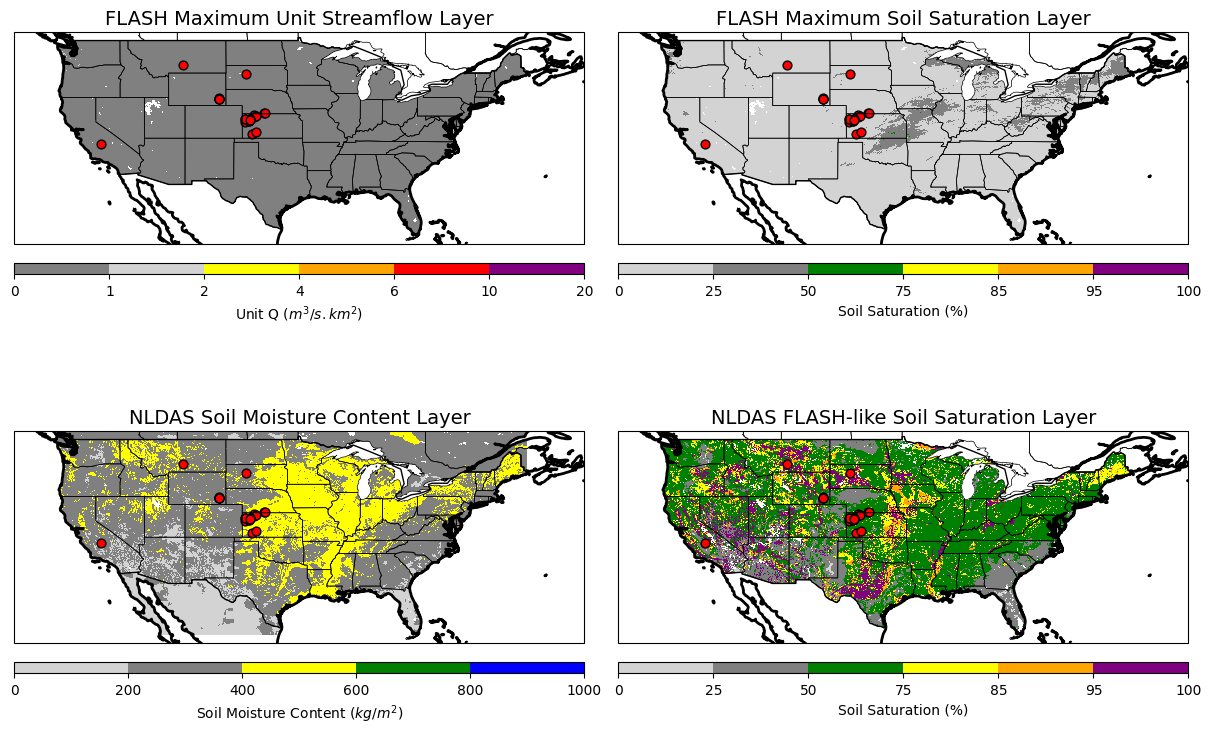

In [35]:
# Create a 4-panel figure
fig, axs = plt.subplots(
    2, 2, figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# Define general graphic settings
map_extent_for_graph = [lon_min, lon_max, lat_min, lat_max]

# FLASH PLOTTING FUNCTION
def plot_FLASH(c_ax,map_extent,flash_product,dataArray,reports,sub_title):
    # Color - 
    all_products = {'unitq':{'label':r'Unit Q ($m^3/s.km^2$)', 'graphpars':{'clims':[0,20], 'clevs':[0,1,2,4,6,10,20], 'colors':['grey', 'lightgrey', 'yellow', 'orange', 'red', 'purple']}},
                'soilsat':{'label':r'Soil Saturation (%)', 'graphpars':{'clims':[0,100], 'clevs':[0,25,50,75,85,95,100], 'colors':['lightgrey', 'grey', 'green', 'yellow', 'orange', 'purple']}},
                   'nldas':{'label':r'Soil Moisture Content ($kg/m^2$)', 'graphpars':{'clims':[0,1000], 'clevs':[0,200,400,600,800,1000], 'colors':['lightgrey', 'grey', 'yellow', 'green', 'blue']}}}
    # FLASH UNIT Q
    ax = axs[c_ax[0], c_ax[1]]

    ax.set_extent(map_extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=2)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.add_feature(cfeature.STATES, linewidth=0.5)

    clevs = all_products[flash_product]['graphpars']['clevs']
    colors = all_products[flash_product]['graphpars']['colors']
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(clevs, cmap.N)

    dataArray = dataArray.where(dataArray >= 0)
    
    # Create colored mesh
    mesh = dataArray.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.scatter(
        reports.LON,
        reports.LAT,
        color="red",
        s=40,
        marker="o",
        edgecolor="black",
        label="Local Storm Reports",
        transform=ccrs.PlateCarree()
    )

    # Add colorbar (legend) to explain colors
    cb = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
    cb.set_label(all_products[flash_product]['label'])  # label explains what the numbers mean

    # Add title at the top
    ax.set_title(sub_title, fontsize=14)

# FLASH UNIT Q
current_ax = [0,0]
this_flash_product = 'unitq'
this_dataArray = flas_uq_da
plot_FLASH(current_ax,map_extent_for_graph,this_flash_product,this_dataArray, filtered, 'FLASH Maximum Unit Streamflow Layer')

# FLASH SOIL SATURATION
current_ax = [0,1]
this_flash_product = 'soilsat'
this_dataArray = flas_soil_da
plot_FLASH(current_ax,map_extent_for_graph,this_flash_product,this_dataArray,  filtered, 'FLASH Maximum Soil Saturation Layer')

# NLDAS SOIL MOISTURE
current_ax = [1,0]
this_flash_product = 'nldas'
this_dataArray = soil_nldas_mrmsgrid
plot_FLASH(current_ax,map_extent_for_graph,this_flash_product,this_dataArray,  filtered, 'NLDAS Soil Moisture Content Layer')

# NLDAS SOIL SATURATION (FLASH Like)
current_ax = [1,1]
this_flash_product = 'soilsat'
this_dataArray = nldas_soil_flash_saturation
plot_FLASH(current_ax,map_extent_for_graph,this_flash_product,this_dataArray,  filtered, 'NLDAS FLASH-like Soil Saturation Layer')

# Save as Figure
# plt.savefig('FLASH_Soil_Analysis_for_' + case_dt.strftime('%Y%m%d%H%M') + '.png', dpi=150)

# # Show figure
plt.show()

The analysis above helps visualizing differences, but we can compute them explicitly 

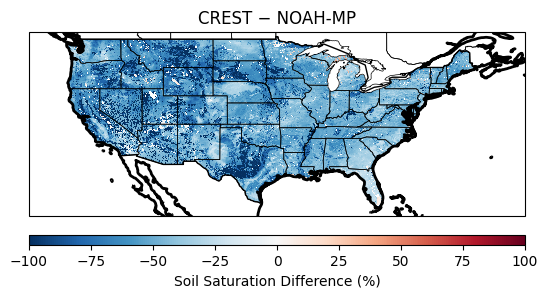

In [36]:
soil_diff = flas_soil_da - nldas_soil_flash_saturation

# Plot Map

# Define general graphic settings
map_extent_for_graph = [lon_min, lon_max, lat_min, lat_max]

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent(map_extent_for_graph, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=2)
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.STATES, linewidth=0.5)

mesh = soil_diff.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-100,
    vmax=100,
    add_colorbar=False
)

cb = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cb.set_label('Soil Saturation Difference (%)')  # label explains what the numbers mean

plt.title("CREST − NOAH‑MP")
plt.show()

### Concept Sidebar — Clustering

**Clustering** is an unsupervised learning technique used to identify natural groupings in data without predefined labels.

In this application, clustering helps us answer:
“Are there spatial regions where FLASH systematically differs from an independent soil moisture estimate?”

We are clustering soil saturation differences, not errors — interpretation requires hydrologic context.

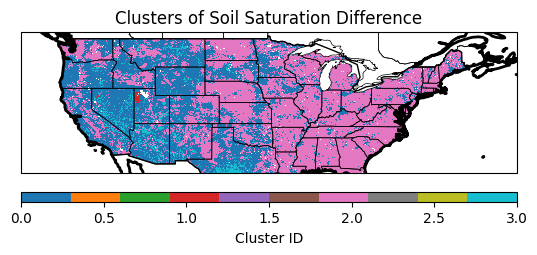

In [11]:
# Prepare data for clustering
X = soil_diff.values.reshape(-1, 1)
mask = np.isfinite(X[:, 0])

# K-means clustering
kmeans = KMeans(n_clusters=4, random_state=0)
labels = np.full(X.shape[0], np.nan)
labels[mask] = kmeans.fit_predict(X[mask])

cluster_map = labels.reshape(soil_diff.shape)

# Convert Numpy Array from clustering to an XArray
cluster_da = xr.DataArray(
    data=cluster_map,
    dims=soil_diff.dims,
    coords=soil_diff.coords,
    name="soil_diff_cluster"
)

# Plot Map

# Define general graphic settings
map_extent_for_graph = [lon_min, lon_max, lat_min, lat_max]

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_extent(map_extent_for_graph, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=2)
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.STATES, linewidth=0.5)

mesh = cluster_da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="tab10",
    add_colorbar=False
)

cb = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cb.set_label('Cluster ID')  # label explains what the numbers mean

plt.title("Clusters of Soil Saturation Difference")
plt.show()

Step 4 — Linking Soil States to Impacts (Segmentation)
Associate LSRs with Gridded Fields

In [12]:
# Sample Unit Q and soil difference at LSR locations
y_coords = flas_uq_da["y"].values
x_coords = flas_uq_da["x"].values

filtered_gdf = gpd.GeoDataFrame(
    filtered,
    geometry=gpd.points_from_xy(filtered["LON"], filtered["LAT"]),
    crs="EPSG:4326"
)

def nearest_idx(array, value):
    return np.abs(array - value).argmin()

filtered_gdf["unit_q"] = [
    flas_uq_da.values[
        nearest_idx(y_coords, row.geometry.y),
        nearest_idx(x_coords, row.geometry.x)
    ]
    for _, row in filtered_gdf.iterrows()
]

filtered_gdf["soil_diff"] = [
    soil_diff.values[
        nearest_idx(y_coords, row.geometry.y),
        nearest_idx(x_coords, row.geometry.x)
    ]
    for _, row in filtered_gdf.iterrows()
]

### Concept Sidebar — Segmentation ###

Segmentation is a computer‑vision technique that groups neighboring pixels into coherent spatial objects.
In hydrology, segmentation allows us to move from pixel‑level signals to physically meaningful regions
like impacted areas or problematic zones.
Here, segmentation helps us identify contiguous regions associated with flood impacts.

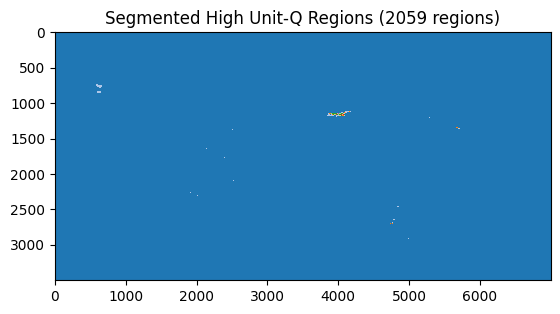

In [13]:
# Identify high Unit Q regions
uQTH = 1 # Based on prior experiences with FLASH
high_q = flas_uq_da.values > uQTH

# Label contiguous regions
labeled_regions, num = ndimage.label(high_q)

plt.imshow(labeled_regions, cmap="tab20")
plt.title(f"Segmented High Unit-Q Regions ({num} regions)")
plt.show()

Step 5 — Classification of Flood Signal Performance
Build Classification Dataset

In [14]:
# Create binary impact label (LSR present vs not)
# Using proximity-based labeling for raster cells

impact_mask = np.zeros(flas_uq_da.shape, dtype=int)

for _, row in filtered_gdf.iterrows():
    iy = nearest_idx(y_coords, row.geometry.y)
    ix = nearest_idx(x_coords, row.geometry.x)
    impact_mask[iy, ix] = 1

# Feature matrix
features = np.column_stack([
    flas_uq_da.values.flatten(),
    soil_diff.values.flatten()
])

labels = impact_mask.flatten()

mask = np.isfinite(features).all(axis=1)
X = features[mask]
y = labels[mask]

📘 Concept Sidebar — Classification

Classification is a supervised learning technique where models learn relationships between predictors and predefined labels.
In this activity, classification helps answer:
“How does soil saturation consistency affect the ability of Unit Streamflow to indicate real impacts?”
Importantly, our labels are imperfect proxies, and model results must be interpreted cautiously.

**Train Classification Model**

In [15]:
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X, y)

y_pred = clf.predict(X)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   8047852
           1       1.00      0.87      0.93        46

    accuracy                           1.00   8047898
   macro avg       1.00      0.93      0.97   8047898
weighted avg       1.00      1.00      1.00   8047898



**Visualize Impact Prediction**

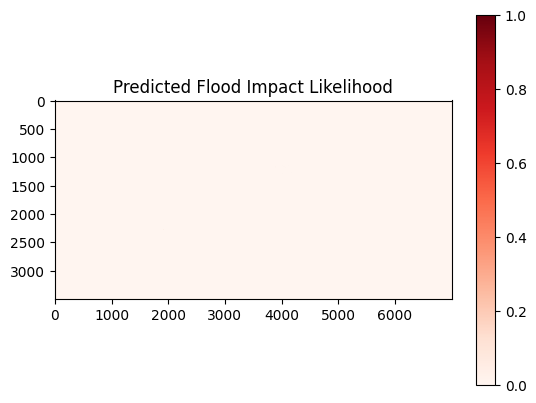

In [16]:
pred_map = np.zeros(labels.shape)
pred_map[mask] = clf.predict(features[mask])
pred_map = pred_map.reshape(flas_uq_da.shape)

plt.imshow(pred_map, cmap="Reds")
plt.title("Predicted Flood Impact Likelihood")
plt.colorbar()
plt.show()

### Reflection Questions

1. Where do large discrepancies between FLASH and NOAH‑MP soil saturation occur?
2. Are these discrepancies spatially organized?
3. Does Unit Streamflow perform differently depending on soil saturation agreement?
4. What limitations arise from using LSRs as impact indicators?
5. How might these diagnostics support real‑time forecasting?